# TALISMAN: Take-home exercise

### Set up

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from talisman import LaserEnv
from scipy.optimize import curve_fit

#### Building the bench. 

This uses my token (from email) 

Token = 808c34f6a0

In [2]:
TOKEN = "808c34f6a0"

if TOKEN == "YOUR_TOKEN":                   ## this line stays as your token

    raise ValueError(
        "Paste your personal token from the invitation email into TOKEN above. "
        "Any string builds a valid bench, so without your own token you would "
        "silently work on the wrong one."
    )

env = LaserEnv(token=TOKEN)         # main control interface
obs, info = env.reset()             # Restarts the simulation to a clean initial state and puts the system in a known starting configuration

#### Task 1: Measuring the laser spot well

The current `crude_centroid` gives a pixel coordinate for the centre of the laser but does not indicate how reliable it is. With this method it does not take into acount the shape of the spot, senitivity to intentisty flucuations or leaks from background noise estimates (potential dark current pixels). 

Instead the laser spot should be treated as a gaussian blob. Giving it a wieghting which is more realistic. 

$I(x,y)=Aexp(−\frac{(x - x0)^2}{2\sigma_x^2}−\frac{(y - y0)^2}{2\sigma_y^2}) + B$

In [3]:
# fitting guassian

def gaussian_2d(coords, A, x0, y0, sx, sy, B):
    x, y = coords
    return (
        A * np.exp(-(((x - x0)**2) / (2 * sx**2) + ((y - y0)**2) / (2 * sy**2))) + B
    ).ravel()

def fit_gaussian(obs):
    image = obs["image"].astype(float)
    y, x = np.indices(image.shape)                                                   # produces x and y coordinate for every value

    beam = np.clip(image - np.median(image), 0.0, None)                              # initial guess from crude centroid def in getting_started.ipynb
    total = beam.sum()                                                               # np.clip removes negative values, total is the brightness of detected spot
    x0 = (beam * x).sum() / total
    y0 = (beam * y).sum() / total
    A0 = beam.max()
    B0 = np.median(image)
    sx0 = sy0 = 2.0                                                                  # inital starting guess

    p0 = [A0, x0, y0, sx0, sy0, B0]

    bounds = (                                                                       # bounds (prevents nonsense fits)
        [0, 0, 0, 0.5, 0.5, 0],
        [np.inf, 63, 63, 20, 20, np.inf]
    )
    popt, pcov = curve_fit(gaussian_2d, (x, y), image.ravel(), p0=p0, bounds=bounds)
    A, x0, y0, sx, sy, B = popt
    perr = np.sqrt(np.diag(pcov))                                                    # uncertainty estimate from covariance
    x0_err, y0_err = perr[1], perr[2]

    return {
        "x": x0,
        "y": y0,
        "sx": sx,
        "sy": sy,
        "x_err": x0_err,
        "y_err": y0_err,
        "A": A,
        "B": B
    }

    obs, info = env.reset()

precise_measurement = fit_gaussian(obs)
x = (precise_measurement["x"])
y = (precise_measurement["y"])
x_err = (precise_measurement["x_err"])
y_err = (precise_measurement["y_err"])

def define_centroid(obs):
    results = fit_gaussian(obs)
    return results["x"], results["y"]

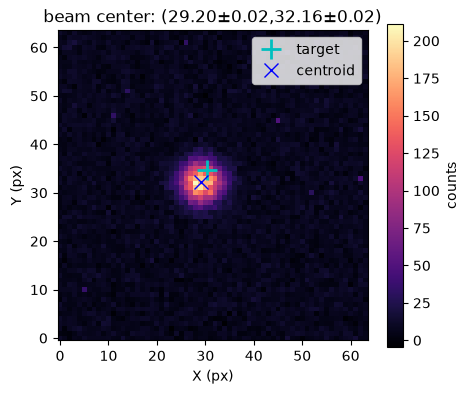

In [4]:
# Plot and measurement result

fig, ax = plt.subplots(figsize=(5, 4.2))
im = ax.imshow(obs["image"], origin="lower", cmap="magma")
fig.colorbar(im, ax=ax, label="counts")
target = info["target"]
ax.plot(*target, "c+", markersize=14, markeredgewidth=2, label="target")
ax.plot(x, y, "bx", markersize=10, label="centroid")
ax.set_title(f"beam center: ({x:.2f}\u00B1{x_err:.2f},{y:.2f}\u00B1{y_err:.2f})")
ax.set_xlabel("X (px)")
ax.set_ylabel("Y (px)")
ax.legend()
plt.show()

#### Task 2: Watch how the laser spot moves

In [5]:
# logging a run code from getting_started.ipynb

def log_run(env, n, action=None):
    """Step the bench n times, collecting arrays. `action` is a single
    length-2 command sent UNCHANGED on every one of the n steps (default
    zero = passive watching). For a time-varying command, edit the loop to
    index a per-step sequence instead."""
    action = np.zeros(2) if action is None else np.asarray(action, float)
    env.reset()
    cx, cy = np.empty(n), np.empty(n)
    sensors = np.empty((n, len(env.sensor_names)))
    for i in range(n):
        obs, _, _, _, info = env.step(action)
        cx[i], cy[i] = define_centroid(obs)
        sensors[i] = list(obs["sensors"].values())
    return dict(t=np.arange(1, n + 1), cx=cx, cy=cy, sensors=sensors)

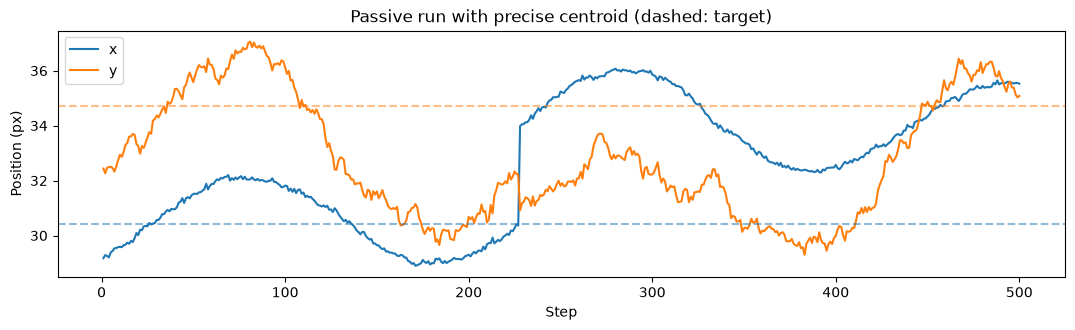

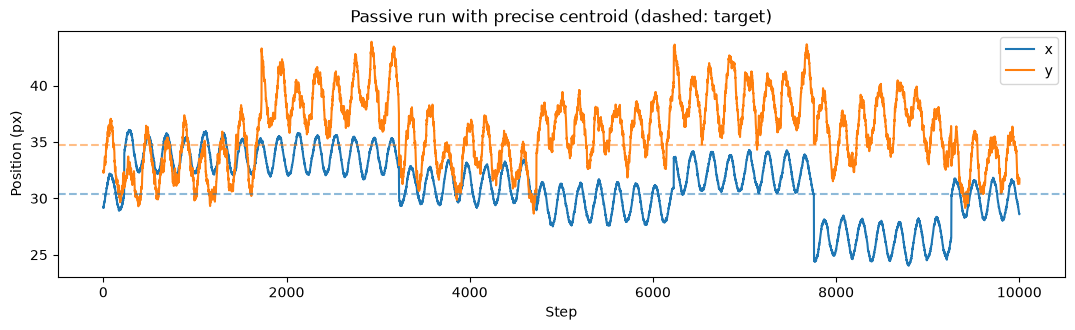

Range in x postion: 12.04 px 
Range in y position: 15.24 px


In [6]:
# plotting
def plot_run(n):
    run = log_run(env, n, action=None)
    fig, ax = plt.subplots(figsize=(13, 3.2))
    ax.plot(run["t"], run["cx"], label="x")
    ax.plot(run["t"], run["cy"], label="y")
    ax.axhline(target[0], ls="--", color="C0", alpha=0.5)
    ax.axhline(target[1], ls="--", color="C1", alpha=0.5)
    ax.set_xlabel("Step")
    ax.set_ylabel("Position (px)")
    ax.set_title("Passive run with precise centroid (dashed: target)")
    ax.legend()
    plt.show()

plot_run(500)
plot_run(10000)

run = log_run(env, 10000, action=None)
cx_range = np.max(run["cx"]) -np.min(run["cx"])                                            # looking at range of pixel position 
cy_range = np.max(run["cy"]) -np.min(run["cy"])

print(f"Range in x postion: {cx_range:.2f} px \nRange in y position: {cy_range:.2f} px")

#### Discussion of results for Task 2

Both x (blue) and y (orange) show a high-frequency periodic ripple, with roughly constant amplitude oscillation persistent over the entire run. Both axes have a similar freqeuncy as well. This is likely from systematic periodic motion instead of noise such as mechanical vibration or actuator feedback oscillation. 

When n was small oscillations were not shown well with the pixel position looking like it was heading to an equilibrium. When n is increased (in this case to 10,000) the equilibrium itself shifts over time. There are discreet jumps where the system jumps to a new operating point which could be due to control reponses or nonlinear actuator response. 

For the first graph n = 500 and the detail of small flucuations is much clearer. The y position flucuates a lot more between steps but is smoother overall whereas the x position has a very neat sineusoidal curve but has a much larger jump around step n = 225. This suggests the x and y axis are not controlled equally, potentially the x-axis is more directly actuator-driven whilst the y axis is more sensitive to environmental drift or coupling. 


#### Task 3: What do the actuators actually do? 

To investigate what each actuator actually does there are three parts to consider: in what direction does the actuator move the spot, by how far does it move it (the magnitude) and how fast does the actuator respond to a command. 

To consider direction and magnitude 5 runs were logged. These included a baseline where the action was [0,0] and then 4 others: [-1,0], [1,0], [0,-1] and [0,1]. The positions of the center pixel were plotted against the baseline to determine what direction the actuators moved the spot and the difference between the baseline pixel and the new center pixel was used to determine the magnitude. 

To determine how fast the actuators would respond to commands `log_run` was changed so the actions could be added at speficed times. In this case two runs were completed the first with an action of [1,0] and [-1,0] in pulses so it was possible to see how the actuator responded to a command and how the system went back to it's baseline when the command was stopped. The second run at two actions [0,1] and [0,-1]. 

Running Baseline : [0, 0]
Running +X : [1, 0]
Running -X : [-1, 0]
Running +Y : [0, 1]
Running -Y : [0, -1]


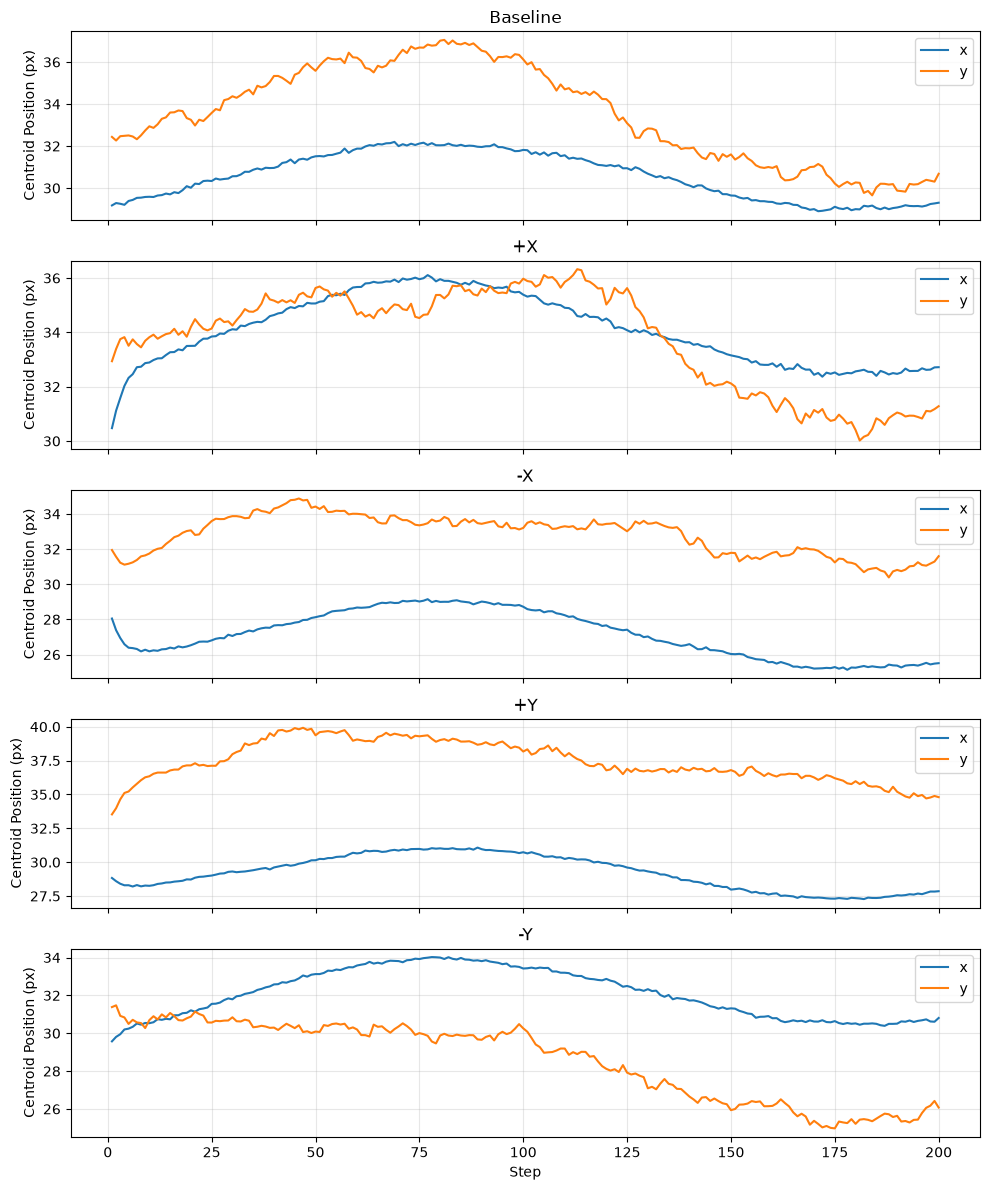

In [7]:
# Parameters 
n = 200

experiments = {
    "Baseline": [0, 0],
    "+X": [1, 0],
    "-X": [-1, 0],
    "+Y": [0, 1],
    "-Y": [0, -1],
}

runs = {}
for name, action in experiments.items():
    print(f"Running {name} : {action}")
    runs[name] = log_run(env, n, action=action)

fig, axes = plt.subplots(5, 1, figsize=(10, 12), sharex=True)

for ax, (name, run) in zip(axes, runs.items()):
    ax.plot(run["t"], run["cx"], label="x", linewidth=1.5)
    ax.plot(run["t"], run["cy"], label="y", linewidth=1.5)
    ax.set_ylabel("Centroid Position (px)")
    ax.set_title(name)
    ax.grid(alpha=0.3)
    ax.legend()

axes[-1].set_xlabel("Step")
plt.tight_layout()
plt.show()

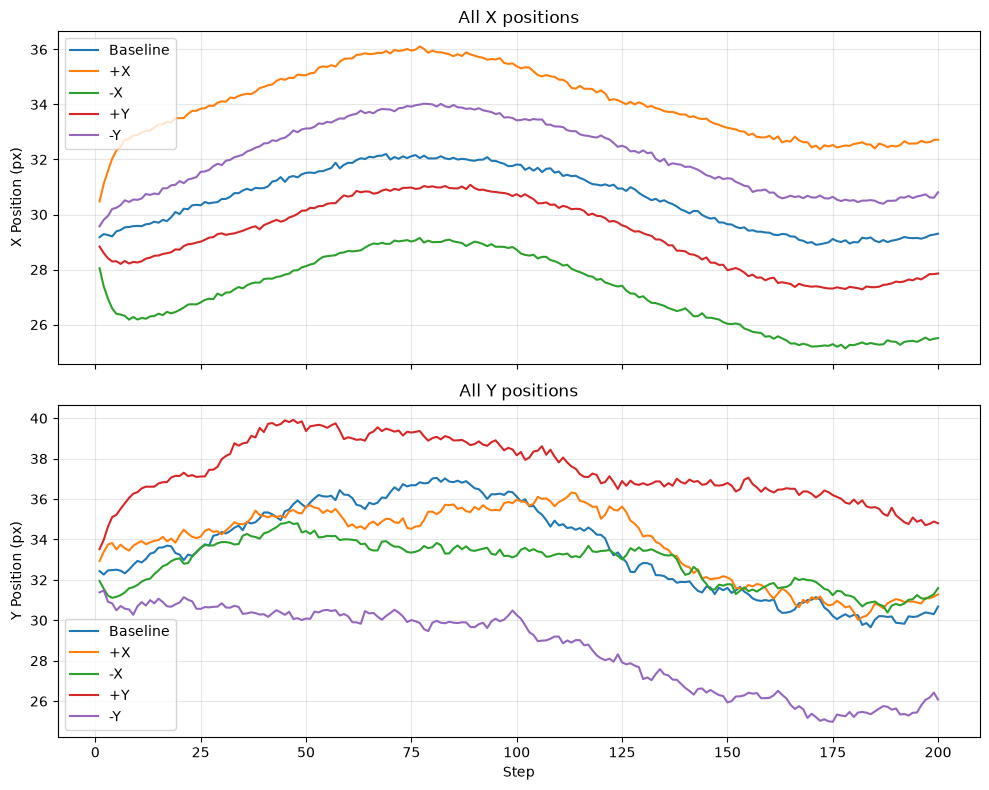

In [8]:
# plot x and y positions in each run against each other. 

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

for name, run in runs.items():
    axes[0].plot(run["t"], run["cx"], label=name)

axes[0].set_ylabel("X Position (px)")
axes[0].set_title("All X positions")
axes[0].grid(alpha=0.3)
axes[0].legend()

for name, run in runs.items():
    axes[1].plot(run["t"], run["cy"], label=name)

axes[1].set_xlabel("Step")
axes[1].set_ylabel("Y Position (px)")
axes[1].set_title("All Y positions")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

From these graphs it is possible to determine in which direction the actuator effects the central pixel. The first actuator (+X and -X) effects the x position of the central pixel and the second actuator (+Y and -Y) affects the y position of the central pixel. In the first graph which plots the x postion of the center pixel over 10,000 steps shows the +X and -X runs had the largest difference to the baseline (blue) line whereas in the second graph the +Y and -Y have the biggest difference from the baseline suggesting this actuator changes the y position. 

For a reminder: 
* "Baseline": [0, 0]
* "+X": [1, 0]
* "-X": [-1, 0]
* "+Y": [0, 1]
* "-Y": [0, -1]

For the first actuator 1 wold move the spot to the right of the sensor and -1 moves the spot to the left. 

For the second actuator 1 would move the spot up on the sensor and -1 moves the spot down. 

+X: max displacement = 4.06 px
-X: max displacement = 3.93 px
+Y: max displacement = 1.88 px
-Y: max displacement = 1.98 px
+X: max displacement = 2.54 px
-X: max displacement = 3.72 px
+Y: max displacement = 6.17 px
-Y: max displacement = 7.34 px


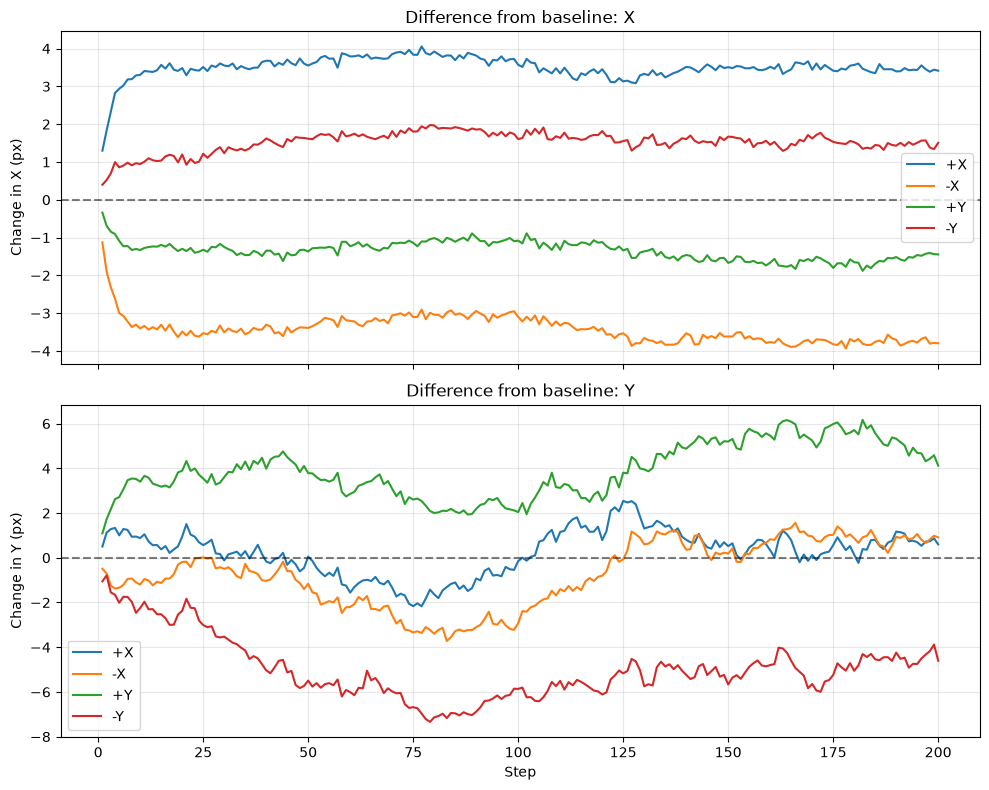

In [9]:
# how far from the baseline do they shift? 

baseline_x = runs["Baseline"]["cx"]
baseline_y = runs["Baseline"]["cy"]

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

for name, run in runs.items():
    if name == "Baseline":
        continue
    dx = run["cx"] - baseline_x
    max_dx = np.max(np.abs(dx))
    print(f"{name}: max displacement = {max_dx:.2f} px")
    axes[0].plot(run["t"], dx, label=name)

axes[0].axhline(0, color="k", linestyle="--", alpha=0.5)
axes[0].set_ylabel("Change in X (px)")
axes[0].set_title("Difference from baseline: X")
axes[0].grid(alpha=0.3)
axes[0].legend()

for name, run in runs.items():
    if name == "Baseline":
        continue
    dy = run["cy"] - baseline_y
    max_dy = np.max(np.abs(dy))
    print(f"{name}: max displacement = {max_dy:.2f} px")
    axes[1].plot(run["t"], dy, label=name)

axes[1].axhline(0, color="k", linestyle="--", alpha=0.5)
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Change in Y (px)")
axes[1].set_title("Difference from baseline: Y")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

The first actuator moves the spot a maximum of 4.06 pixels to the right of the sensor and 3.93 pixels to the left of the sensor during a run of 10,000 steps. 

The second actuator moves the spot a maximum of 6.17 pixels up on the sensor and 7.34 pixels down on the sensor during a run of 10,000 steps.

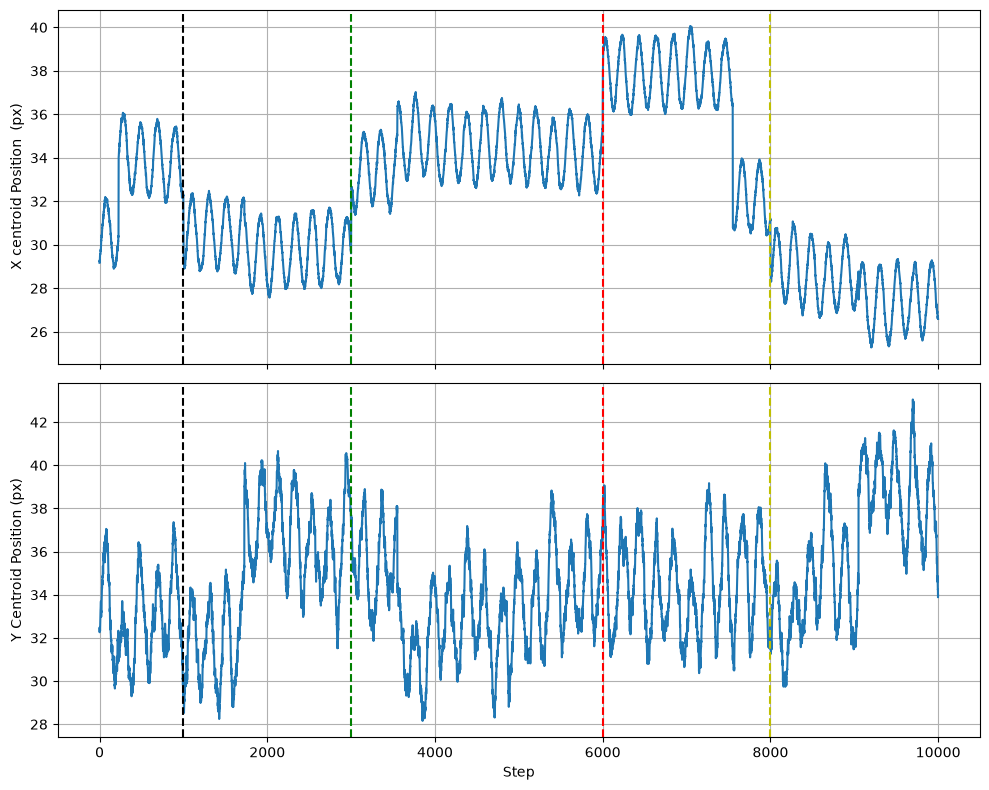

In [10]:
def log_run_sequence(env, actions):
    """
    actions: (n,2) array containing actuator command at every step
    """
    n = len(actions)
    env.reset()
    cx = np.empty(n)
    cy = np.empty(n)
    for i in range(n):
        obs, *_ = env.step(actions[i])
        cx[i], cy[i] = define_centroid(obs)
    return {
        "t": np.arange(n),
        "cx": cx,
        "cy": cy,
        "actions": actions
    }

n = 10000
actions = np.zeros((n, 2))
time1 = 1000
time2 = 3000
actions[time1:time2] = [-1, 0]
time3 = 6000
time4 = 8000
actions[time3:time4] = [1, 0]

run = log_run_sequence(env, actions)

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
axes[0].plot(run["t"], run["cx"])
axes[0].axvline(time1, color="k", ls="--")
axes[0].axvline(time2, color="g", ls="--")
axes[0].axvline(time3, color="r", ls="--")
axes[0].axvline(time4, color="y", ls="--")
axes[0].set_ylabel("X centroid Position  (px)")
axes[0].grid()

axes[1].plot(run["t"], run["cy"])
axes[1].axvline(time1, color="k", ls="--")
axes[1].axvline(time2, color="g", ls="--")
axes[1].axvline(time3, color="r", ls="--")
axes[1].axvline(time4, color="y", ls="--")
axes[1].set_ylabel("Y Centroid Position (px)")
axes[1].set_xlabel("Step")
axes[1].grid()

plt.tight_layout()
plt.show()

In this section the top plot is important as the actuators are directly are influencing the x position of the centroid. Between 1000 and 3000 a pulse of [-1,0] is actioned and it is clear the x positon moves to the left (a smaller number) after 3000 it moves back to the baseline position before moving to the right at n=6000 when a action of [1,0] is introduced. 

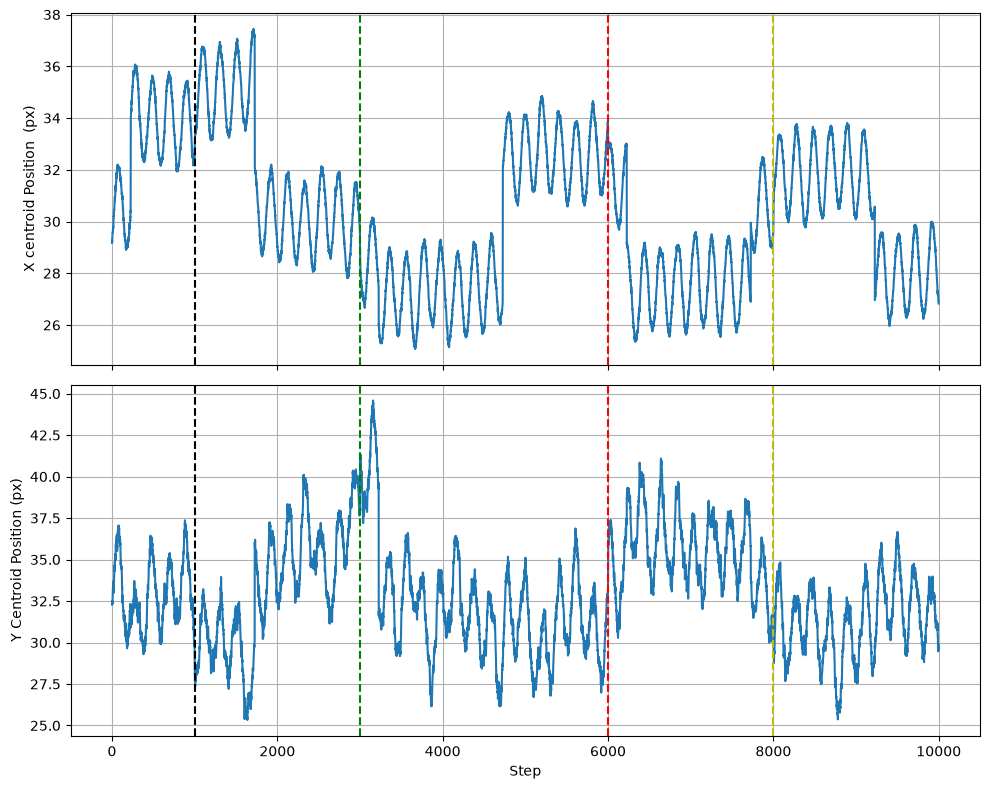

In [11]:
n = 10000
actions = np.zeros((n, 2))
time1 = 1000
time2 = 3000
actions[time1:time2] = [0, -1]
time3 = 6000
time4 = 8000
actions[time3:time4] = [0, 1]

run = log_run_sequence(env, actions)

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
axes[0].plot(run["t"], run["cx"])
axes[0].axvline(time1, color="k", ls="--")
axes[0].axvline(time2, color="g", ls="--")
axes[0].axvline(time3, color="r", ls="--")
axes[0].axvline(time4, color="y", ls="--")
axes[0].set_ylabel("X centroid Position  (px)")
axes[0].grid()

axes[1].plot(run["t"], run["cy"])
axes[1].axvline(time1, color="k", ls="--")
axes[1].axvline(time2, color="g", ls="--")
axes[1].axvline(time3, color="r", ls="--")
axes[1].axvline(time4, color="y", ls="--")
axes[1].set_ylabel("Y Centroid Position (px)")
axes[1].set_xlabel("Step")
axes[1].grid()

plt.tight_layout()
plt.show()

In the plot the bottom subplot is most important as the second actuator affects the y position of the centroid. Unlike the first run, the changes in position due to commands are less obvious however there is a clear increase in pixel position between 1000 and 3000 and a decrease in postiion between 6000 and 8000 which agrees with the command sent to the actuator. 
The actuator takes a while at 3000 to respond to the lack to command and takes about 250 steps before it reaches back to the baseline. 

#### Task 4: Look at the telemetry

First the sensor info was plotted from the logged run to seee how the sensor values changed over time. This was useful for identifying periodic behaviour, anomalies and compare different sensors. 

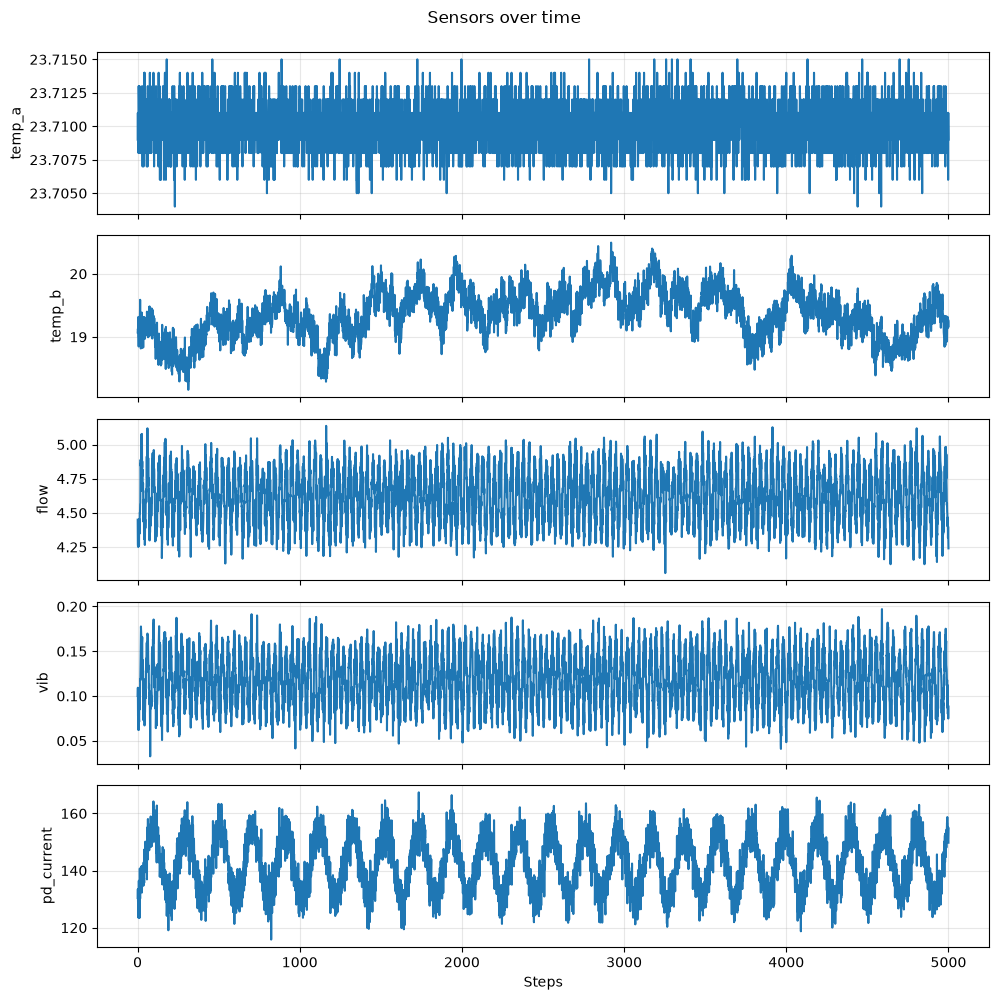

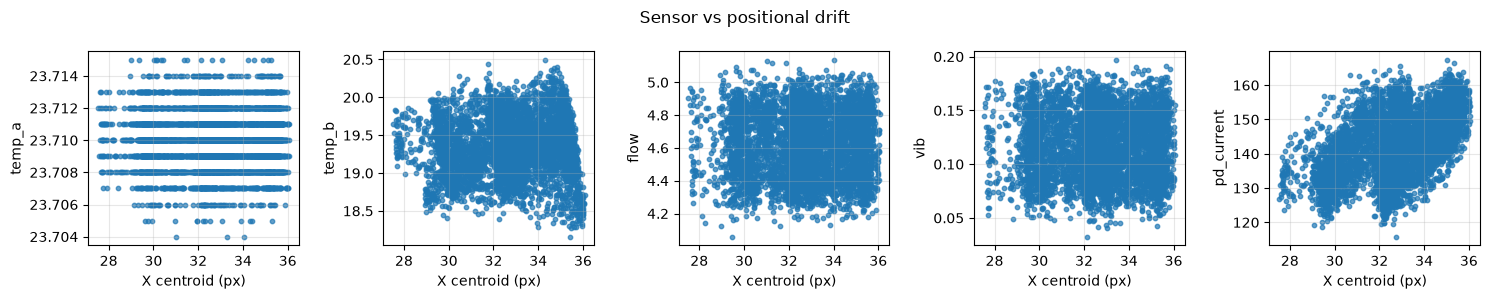

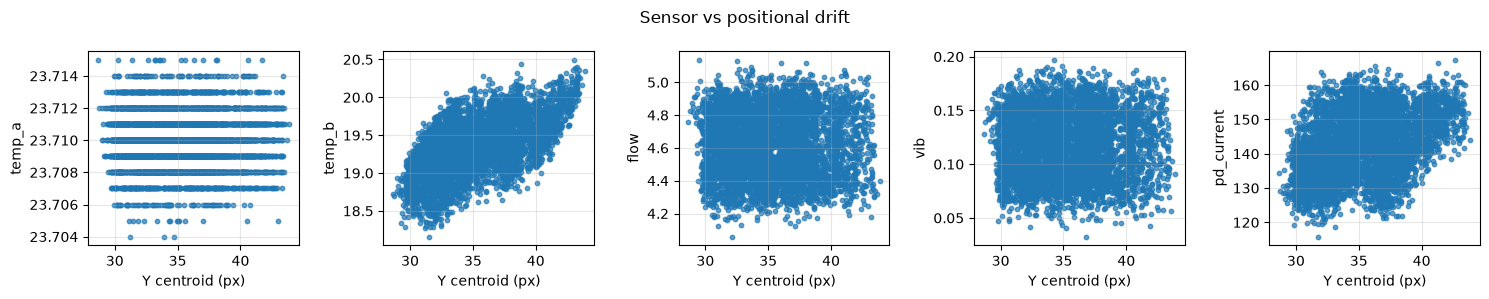

temp_a       corr(cx)=-0.002 corr(cy)=+0.003
temp_b       corr(cx)=+0.028 corr(cy)=+0.607
flow         corr(cx)=+0.003 corr(cy)=+0.003
vib          corr(cx)=-0.001 corr(cy)=+0.006
pd_current   corr(cx)=+0.520 corr(cy)=+0.391


In [ ]:
run = log_run(env, 5000, action=None)               # n = 5000 was used here so patterns in time series cold be seen clearer. 
t = run["t"]
cx, cy = run["cx"], run["cy"]
sensors = run["sensors"]
sensor_names = list(obs["sensors"].keys()) # ['temp_a', 'temp_b', 'flow', 'vib', 'pd_current']

fig, axes = plt.subplots(len(sensor_names), 1, figsize=(10, 10), sharex=True)

# plot sensors
for i, name in enumerate(sensor_names):
    axes[i].plot(t, sensors[:, i])
    axes[i].set_ylabel(name)
    axes[i].grid(alpha=0.3)
axes[-1].set_xlabel("Steps")
plt.suptitle("Sensors over time", y=0.995)
plt.tight_layout()
plt.show()

# plot scatter plots

fig, axes = plt.subplots(1, len(sensor_names), figsize=(15, 3))

for i, name in enumerate(sensor_names):
    axes[i].scatter(run["cx"], sensors[:, i], s=10, alpha=0.7)
    axes[i].set_xlabel("X centroid (px)")
    axes[i].set_ylabel(name)
    axes[i].grid(alpha=0.3)

plt.suptitle("Sensor vs positional drift")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, len(sensor_names), figsize=(15, 3))

for i, name in enumerate(sensor_names):
    axes[i].scatter(run["cy"], sensors[:, i], s=10, alpha=0.7)
    axes[i].set_xlabel("Y centroid (px)")
    axes[i].set_ylabel(name)
    axes[i].grid(alpha=0.3)

plt.suptitle("Sensor vs positional drift")
plt.tight_layout()
plt.show()

# correlation

for i, name in enumerate(sensor_names):
    corr_x = np.corrcoef(run["cx"], sensors[:, i])[0, 1]
    corr_y = np.corrcoef(run["cy"], sensors[:, i])[0, 1]
    print(f"{name:12s} corr(cx)={corr_x:+.3f} corr(cy)={corr_y:+.3f}")

#### Discussion of Task 4

The 5 sensors correspond to temperatures (a and b) of different components, flow (coolant or gas flow rate) used to maintain a steady temperature and prevent overheading, amount of vibration in the hardware and photodiode current. The photodiode current is porpotional to the laser intensity hitting the sensor. When the spot moves the intensity changes as well. The photodiode current has a similar freqeuncy of oscillation as the centorid position in the x axis sugessting a strong and real realtionship between them. 

Another interesting comparison is the difference between temp_a and temp_b. Temp_a is fairly stable and could refer to a control loop output or sensor placed on a thermally isolated component whereas temp_b has a distincitve oscillation affected differently in the x and y directions when looking at the scatter plots. This sensor is liekly closer to the heat source or less filtered compared to sesnor temp_a. 

The flow and vibration level have almost no correlation with the movement of the center pixel and carry limited information about the system. 